## Imports an libraries

In [1]:
# Enable inline plots in the notebook
%matplotlib inline

# Import library functions needed
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.animation as animation
from IPython.display import clear_output
from IPython.display import HTML
from scipy.stats import multivariate_normal  # we'll use this for clean Gaussian
#from IPython.core.debugger import set_trace # Activates debugging features

def rasterplot(ax, x, y, x_label, y_label):
# Function used to plot spike times
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    ax.scatter(x, y, marker='|')
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    

# Set default figure size (Might not be needed?)
plt.rcParams['figure.figsize'] = [10, 10]


## Dataset Generator
 Dataset Generator
    
Generates a sequence of frames showing a single pixel
moving horizontally across the frame.

Parameters:
* frame_x (int): Width of frame.
* frame_y (int): Hight of frame.
* seq_length (int): Number of frames in sequence.
* initial_direction (string): "right" or "left". 
* speed (int): Pixels moved per frame.
* noise_level (float): pixel noise.
* p_right, p_left, p_stop (float): probability the dot moves right, left and stands still

Returns:
* numpy array of shape (seq_length, frame_y, frame_x)

In [2]:
def generate_motion_sequence(
    frame_x=64,
    frame_y=10,
    seq_length=60,
    initial_direction="right",  # changed default to match common use
    speed=1,
    noise_level=0.0,
    p_right=0.0,
    p_left=0.0,
    p_stop=0.0,
    blob_sigma=1.4,           # ← controls blob size (try 1.0–2.5)
    blob_amplitude=1.0        # ← peak brightness (≤ 1.0 to stay in [0,1])
):
    frames = []
    y_pos = np.random.randint(3, frame_y - 3)  # give some room for the blob
    
    # Start position
    if initial_direction == "right":
        x = 2.0                     # start a bit inside
    elif initial_direction == "left":
        x = frame_x - 3.0
    else:
        x = frame_x / 2

    # Create coordinate grid once (for efficiency)
    y_grid, x_grid = np.mgrid[0:frame_y, 0:frame_x]
    grid = np.stack([y_grid.ravel(), x_grid.ravel()], axis=-1)  # shape (H*W, 2)

    for t in range(seq_length):
        frame = np.zeros((frame_y, frame_x))
        
        # Current center (sub-pixel precision is fine)
        center = np.array([y_pos, x])
        
        # Gaussian PDF → shape (H*W,)
        rv = multivariate_normal(mean=center, cov=[[blob_sigma**2, 0], [0, blob_sigma**2]])
        pdf_values = rv.pdf(grid)
        
        # Normalize so peak ≈ blob_amplitude
        if pdf_values.max() > 0:
            pdf_values *= blob_amplitude / pdf_values.max()
        
        frame.flat = pdf_values.reshape(frame_y, frame_x)
        
        # Optional: clip (usually not needed if amplitude ≤ 1)
        frame = np.clip(frame, 0, 1)

        # Add noise after the blob (so noise doesn't get normalized away)
        if noise_level > 0:
            noise = np.random.normal(0, noise_level, frame.shape)
            frame += noise
            frame = np.clip(frame, 0, 1)

        frames.append(frame)

        # Probabilistic motion
        motion = np.random.choice(
            ["right", "left", "stop"],
            p=[p_right, p_left, p_stop]
        )
        if motion == "right":
            x += speed
        elif motion == "left":
            x -= speed
        # stop → stays put

        # Optional: keep x inside visible area
        x = np.clip(x, -blob_sigma*3, frame_x + blob_sigma*3)

    return np.array(frames)



def create_dataset(n_samples=1000, seed=None, noise_level=0.0, direction="right", p_right=0.5, p_left=0.5, p_stop=0.0):     #default values, can be overridden when calling the function
    if seed is not None:
        np.random.seed(seed)

    x = []      #Data sequences
    y = []      #Lables

    for _ in range(n_samples):

        seq = generate_motion_sequence(
            initial_direction=direction,
            speed=1,
            noise_level=noise_level,
            p_right=p_right,
            p_left=p_left,
            p_stop=p_stop
        )

        x.append(seq)
        y.append(direction)

    return np.array(x), np.array(y)


# Visualize the data sequence
def animate_sequence(sequence):
    fig, ax = plt.subplots()
    img = ax.imshow(sequence[0], cmap='gray', vmin=0, vmax=1)
    ax.set_axis_off()

    def update(frame):
        img.set_data(sequence[frame])
        return [img]

    ani = animation.FuncAnimation(
        fig, update, frames=len(sequence), interval=200
    )

    plt.close(fig)  # Prevent duplicate static plot
    return HTML(ani.to_jshtml())
x, y = create_dataset(n_samples=3, seed=67, noise_level=0.8, direction="right", p_right=0.8, p_left=0.2, p_stop=0.0) 

animate_sequence(x[0])

## Delta Modulation (Spike Encoding)
Convert pixel changes to spikes

In [3]:
def encode_to_spikes(frames, threshold=0.1):
    """
    Convert frame sequence to spikes using delta modulation.
    Spikes generated when pixel change exceeds threshold.
    
    frames: (T, H, W) - sequence of frames
    Returns: (T, H, W) - binary spike array
    """
    spikes = np.zeros_like(frames)
    
    # Generate spikes for temporal differences
    for t in range(1, len(frames)):
        diff = frames[t] - frames[t-1]
        spikes[t] = (np.abs(diff) > threshold).astype(float)
    
    return spikes

# Prepare spike data from first training sample
frames = x[0]                          # use first training sample
spikes = encode_to_spikes(frames)      # shape (T, H, W)
T, H, W = spikes.shape
N = H * W
spikes_flat = spikes.reshape(T, N)     # each pixel is one presynaptic neuron


In [4]:
# Example: test with your friend's data generator
# frames = generate_motion_sequence(direction="right", seq_length=30)
# spikes = encode_to_spikes(frames, threshold=0.1)
# print(f"Frame shape: {frames.shape}")
# print(f"Spike shape: {spikes.shape}")
# print(f"Total spikes: {spikes.sum()}")

## Simple SNN (Leaky Integrate-and-Fire)

In [5]:
def lif_neuron_simple(input_spikes, weights, threshold=1.0, decay=0.9):
    """
    Simple LIF neuron that processes spike input.
    
    input_spikes: (T, N) - spike trains over time
    weights: (N,) - synaptic weights
    Returns: output spikes over time
    """
    T = len(input_spikes)
    membrane = 0.0
    output_spikes = []
    
    for t in range(T):
        # Integrate input
        membrane = membrane * decay + np.dot(input_spikes[t], weights)
        
        # Fire if threshold reached
        if membrane >= threshold:
            output_spikes.append(1)
            membrane = 0  # Reset
        else:
            output_spikes.append(0)
    
    return np.array(output_spikes)

In [6]:
# Test LIF neuron
# test_spikes = np.random.rand(50, 10) > 0.8  # Random sparse spikes
# test_weights = np.random.randn(10) * 0.5
# output = lif_neuron(test_spikes, test_weights)
# print(f"Output spikes: {output.sum()} out of {len(output)} timesteps")

## STDP

In [ ]:
def lif_neuron(I_inject, E_L=-65e-3, u_reset=-65e-3, u_thres=-50e-3, R=90e6, tau_m=30e-3):
    # LIF neuron with a constant injection current
    return {
        'type'    : 'lif',
        'u'       : u_reset,                   # Membrane potential [Volt]
        'E_L'     : E_L,                       # Leakage resting potential [Volt]
        'u_reset' : u_reset,                   # Reset potential after spike [Volt]
        'u_thres' : u_thres,                   # Threshold for spike generation [Volt]
        'R'       : R,                         # Membrane resistance [Ohm]
        'tau_m'   : tau_m,                     # Membrane time constant [second]
        'I_inj'   : I_inject,                  # Injection current [Ampere]
    }

def lif_syn_neuron(num_synapses, E_L=-65e-3, u_reset=-65e-3, u_thres=-50e-3, R=90e6, tau_m=30e-3, I_inject=0, tau_syn=50e-3):
    # LIF neuron with dynamic synapses
    n = lif_neuron(I_inject, E_L, u_reset, u_thres, R, tau_m)
    n['tau_syn'] = tau_syn                     # Synapse time constant [second] (can also be an array)
    n['I_syn']   = np.zeros(num_synapses)      # Postsynaptic currents [Ampere]
    n['w_syn']   = np.zeros(num_synapses)      # Synaptic weights [Ampere]
    n['type']    = 'lif_syn'
    return n

def lif_stdp_neuron(num_synapses, E_L=-65e-3, u_reset=-65e-3, u_thres=-50e-3, R=90e6, tau_m=30e-3, I_inject=0,
                    tau_syn=50e-3, tau_pls=20e-3, tau_mns=20e-3, w_max=1e-9, w_min=1e-12, gamma=1):
    # LIF neuron with dynamic synapses and pair-based STDP
    n = lif_syn_neuron(num_synapses, E_L, u_reset, u_thres, R, tau_m, I_inject, tau_syn)
    n['x_pre']   = np.zeros(num_synapses)      # STDP trace of presynaptic spikes
    n['y_pst']   = 0                           # STDP trace of postsynaptic spikes (scalar, one neuron)
    n['tau_pls'] = tau_pls                     # STDP trace time constant [second] (can also be an array)
    n['tau_mns'] = tau_mns                     # STDP trace time constant [second] (can also be an array)
    n['w_max']   = w_max                       # Largest allowed value of synapse conductance
    n['w_min']   = w_min                       # Lowest allowed value of synapse conductance
    n['gamma']   = gamma                       # Learning rate parameter with soft bounds (w_min,w_max)
    n['type']    = 'lif_stdp'
    return n

def poisson_neuron(spike_frequency):
    # Random spike generator with Poisson distributed spike time intervals, see Section 7.2.1 in the book
    return {
        'type'      : 'poisson',
        'frequency' : spike_frequency          # Average spiking frequency
    }

def spike_generator(spike_times):
    # Generates spikes at time points defined by the sorted list 'spike_t'
    return {
        'type'      : 'generator',
        'spike_t'   : spike_times              # Array of spike times, separated by at least dt
    }

def integrate(dt, t, neurons):
    # Integrate the membrane potential, postsynaptic currents etc one timestep dt
    for n in neurons:
        if n['type'] == 'lif':
            # Integrate membrane potential
            dudt = (n['E_L'] - n['u'] + n['R']*n['I_inj']) / n['tau_m']
            n['u'] += dt*dudt
        elif n['type'] in ['lif_syn','lif_stdp']:
            # Integrate array of postsynaptic currents, one current for each synapse
            didt = np.divide(-n['I_syn'], n['tau_syn'])
            n['I_syn'] += dt*didt
            # Integrate membrane potential
            dudt = (n['E_L'] - n['u'] + n['R']*(n['I_inj']+sum(n['I_syn']))) / n['tau_m']
            n['u'] += dt*dudt
            # Integrate local traces for pair-based plasticity
            if n['type'] == 'lif_stdp':
                n['x_pre'] -= dt*np.divide(n['x_pre'], n['tau_pls'])       # Eq 19.12
                n['y_pst'] -= dt*np.divide(n['y_pst'], n['tau_mns'])       # Eq 19.13

def spikegen(dt, t, neurons):
    # Implements the non-linear spike generation mechanism
    spikes = []
    for i,n in enumerate(neurons):
        if n['type'] in ['lif','lif_syn','lif_stdp']:
            if n['u'] > n['u_thres']:
                n['u'] = n['u_reset']
                spikes.append(i)
        elif n['type'] == 'poisson':
            if np.random.rand() < dt*n['frequency']:
                spikes.append(i)
        elif n['type'] == 'generator':
            j = np.searchsorted(n['spike_t'], t, side='right')
            if j>0 and t-n['spike_t'][j-1]<dt:
                spikes.append(i)
    return spikes

def update(dt, t, neurons, connections):
    # Update the state of a spiking neural network.
    # Refer to Exercise 3 for a reminder about how to set up connections between neurons.
    integrate(dt, t, neurons)
    spikes = spikegen(dt, t, neurons)

    # Update weights and STDP trace for each postsynaptic spike
    for spike in spikes:
        n = neurons[spike]
        if n['type'] in ['lif_stdp']:
            n['y_pst'] += 1                                         # Eq 19.13
            for i,w in enumerate(n['w_syn']):
                if w > 0:                                           # Excitatory synapses
                    Aplus = n['gamma']*(n['w_max'] - n['w_syn'][i]) # Eq 19.4
                    n['w_syn'][i] += dt*Aplus*n['x_pre'][i]         # Eq 19.14

    # Update synapse currents, weights and STDP traces for each presynaptic spike
    for (post, syn, pre) in connections:
        for spike in spikes:
            if spike == pre:
                n = neurons[post]
                if n['type'] not in ['lif_syn', 'lif_stdp']:
                    print('Error: Spike sent to neuron type without synapses')
                # Update synapse currents
                if n['type'] in ['lif_syn','lif_stdp']:
                    n['I_syn'][syn] += n['w_syn'][syn]
                # Update STDP trace and weight
                if n['type'] in ['lif_stdp']:
                    n['x_pre'][syn] += 1                                   # Eq 19.12
                    if n['w_syn'][syn] > 0:                                # Excitatory synapses
                        Aminus = n['gamma']*(n['w_min'] - n['w_syn'][syn]) # Eq 19.4
                        n['w_syn'][syn] += dt*Aminus*n['y_pst']            # Eq 19.14
    return spikes

# --- Build training dataset: right-moving samples to train the STDP neuron ---
n_train = 50   # number of training samples to simulate (more = more learning time)
x_train, _ = create_dataset(
    n_samples=n_train,
    seed=42,
    noise_level=0.05,
    direction="right",
    p_right=1.0,
    p_left=0.0,
    p_stop=0.0
)

# Encode first sample to get shape info
sample0_spikes = encode_to_spikes(x_train[0])
T_sample, H, W = sample0_spikes.shape
N = H * W
dt = 1e-4          # integration timestep [second] — controls numerical accuracy
frame_dt = 10e-3   # how long each frame lasts in simulation time [second]
                   # 60 frames × 10ms = 600ms per sample, 6000 steps per sample

# Connect input neurons to n_stdp (stays the same for every sample)
connections = []
for i in range(N):
    connections.append([N, i, i])   # [post,syn,pre], see former SNN exercise

# --- Network setup (done once; weights persist across all training samples) ---
n_stdp = lif_stdp_neuron(N)
n_stdp['w_syn'][:] = 50e-12   # small initial weights

# --- Training loop: simulate each sample sequentially so STDP accumulates ---
# Each sample is a separate sequence of inter-frame changes (delta modulation).
# Between samples we reset all transient state (membrane potential, synaptic
# currents, STDP traces) so temporal context does not bleed across sequences.
# Only w_syn (the learned weights) persists.
steps_per_sample = int(T_sample * frame_dt / dt)  # e.g. 60 frames * 10ms / 0.1ms = 6000
print(f"STDP training on {n_train} samples ({steps_per_sample} steps each)...")
for sample_idx in range(n_train):
    # Reset transient state between samples — weights (w_syn) are kept
    n_stdp['u']     = n_stdp['u_reset']            # Membrane potential [Volt]
    n_stdp['I_syn'] = np.zeros(N)                  # Postsynaptic currents [Ampere]
    n_stdp['x_pre'] = np.zeros(N)                  # STDP presynaptic trace
    n_stdp['y_pst'] = 0                            # STDP postsynaptic trace

    # Encode this sample to spikes (inter-frame changes = movement between frames)
    sample_spikes = encode_to_spikes(x_train[sample_idx])  # shape (T, H, W)
    spikes_flat = sample_spikes.reshape(T_sample, N)        # each pixel is one presynaptic neuron

    # Build input spike generators: frame index → physical time via frame_dt
    input_neurons = []
    for i in range(N):
        spike_times = np.where(spikes_flat[:, i] == 1)[0] * frame_dt  # frame index → seconds
        input_neurons.append(spike_generator(spike_times))

    # Neuron population: input generators + the persistent STDP neuron
    neurons = input_neurons + [n_stdp]

    # Run simulation for this sample
    T_sim = T_sample * frame_dt   # 60 frames × 10ms = 600ms per sample
    t = 0.0
    output_spikes_log = []

    while t < T_sim:
        out = update(dt, t, neurons, connections)
        if N in out:   # N is the index of n_stdp in the neuron list
            output_spikes_log.append(t)
        t += dt

    if (sample_idx + 1) % 10 == 0:
        print(f"  Sample {sample_idx+1}/{n_train} — output spikes: {len(output_spikes_log)}")

print("STDP training done.")

# Export learned weights so Evaluation and Visualization cells can use them.
# STDP weights are in Ampere scale (1e-12 to 1e-9), but predict() uses a simple
# LIF with threshold=1.0, so we normalize to [0, 1] to make the scales compatible.
raw_weights = n_stdp['w_syn'].copy()
w_range = raw_weights.max() - raw_weights.min()
if w_range > 0:
    weights = (raw_weights - raw_weights.min()) / w_range  # normalize to [0, 1]
else:
    weights = np.zeros_like(raw_weights)
print(f"Raw weights  — min: {raw_weights.min():.3e}, max: {raw_weights.max():.3e}")
print(f"Norm weights — min: {weights.min():.3f},   max: {weights.max():.3f}, shape: {weights.shape}")


STDP training on 50 samples (5999 steps each)...
  Sample 10/50 — output spikes: 5554


## TRAINING

In [ ]:
def train_snn(x, y, weights, epochs=3):
    n_samples = x.shape[0]
    pre_trace = np.zeros(640) # 32 * 32
    post_trace = 0.0

    print("Training started...")
    for epoch in range(epochs):
        for i in range(n_samples):
            if y[i] == 1: # Only training 'Right' detector on 'Right' samples
                # Converting frames to spikes using Delta Modulator logic
                spike_seq = encode_to_spikes(x[i])
                input_sequence = spike_seq.reshape(len(spike_seq), -1)

                membrane = 0.0
                for t in range(len(input_sequence)):
                    # Integrating LIF Neuron Logic
                    membrane = membrane * 0.9 + np.dot(input_sequence[t], weights)

                    output_spike = 0.0
                    if membrane >= 1.0:
                        output_spike = 1.0
                        membrane = 0.0

                    # Calling STDP - Need to update and implement the update_stdp function
                    #weights, pre_trace, post_trace = update_stdp(
                       # weights, pre_trace, post_trace, input_sequence[t], output_spike
                   # )
        print(f"Epoch {epoch+1} complete.")
    return weights

## Evaluation

In [ ]:
# Test set
x_test, y_test = [], []

for direction, label in [("right", 1), ("left", 0)]:
    x, _ = create_dataset(
        n_samples=200,
        direction=direction,
        p_right=(direction == "right"),
        p_left=(direction == "left"),
        p_stop=0.0
    )
    x_test.append(x)
    y_test.append(np.full(200, label))

x_test = np.concatenate(x_test)
y_test = np.concatenate(y_test)

# Prediction function
def predict(sequence, weights, threshold_spikes=2):
    spikes = encode_to_spikes(sequence)
    input_seq = spikes.reshape(len(spikes), -1)

    membrane = 0.0
    spike_count = 0

    for frame in input_seq:
        membrane = membrane * 0.9 + np.dot(frame, weights)
        if membrane >= 1.0:
            spike_count += 1
            membrane = 0.0

    return int(spike_count > threshold_spikes)

# Compute accuracy
right_acc = np.mean([
    predict(seq, weights) == 1
    for seq in x_test[y_test == 1]
])

left_acc = np.mean([
    predict(seq, weights) == 0
    for seq in x_test[y_test == 0]
])

accuracy = np.mean([
    predict(x_test[i], weights) == y_test[i]
    for i in range(len(x_test))
])

print(f"Right accuracy: {right_acc*100:.2f}%")
print(f"Left accuracy: {left_acc*100:.2f}%")
print(f"Total test accuracy: {accuracy * 100:.2f}%")

Right accuracy: 100.00%
Left accuracy: 0.00%
Total test accuracy: 50.00%


## Visualization

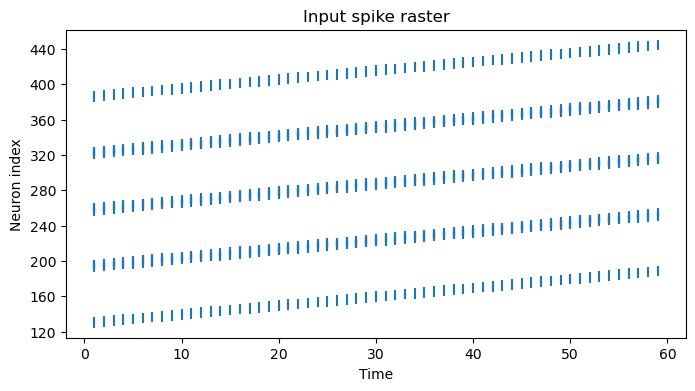

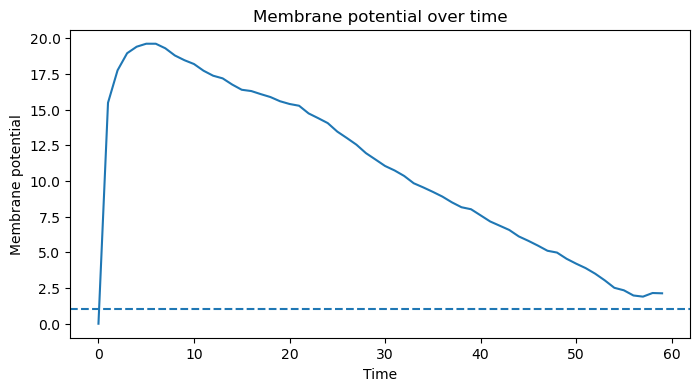

In [ ]:
sample = x_test[0]

# Spike raster plot
spikes = encode_to_spikes(sample)
input_seq = spikes.reshape(len(spikes), -1)

times, neurons = [], []

for t in range(len(input_seq)):
    active = np.where(input_seq[t] > 0)[0]
    for n in active:
        times.append(t)
        neurons.append(n)

fig, ax = plt.subplots(figsize=(8,4))
rasterplot(ax, times, neurons, "Time", "Neuron index")
plt.title("Input spike raster")
plt.show()

# Membrane potential
membrane = 0.0
membrane_trace = []

for frame in input_seq:
    membrane = membrane * 0.9 + np.dot(frame, weights)
    membrane_trace.append(membrane)
    if membrane >= 1.0:
        membrane = 0.0

plt.figure(figsize=(8,4))
plt.plot(membrane_trace)
plt.axhline(1.0, linestyle='--')
plt.xlabel("Time")
plt.ylabel("Membrane potential")
plt.title("Membrane potential over time")
plt.show()

# Training accuracy curve (Append accuracies while training for this to work)
#plt.plot(epoch_accuracies)
#plt.xlabel("Epoch")
#plt.ylabel("Accuracy")
#plt.title("Training accuracy curve")
#plt.show()
